# GPU Tree Search Analysis — 2026-03-23

**Dataset:** DNA, 100 taxa, 10,000 columns, GTR{1.0,2.0,1.0,1.0,3.0} (fixed model)

**Hardware:**
- OpenACC: V100-SXM2-32GB (gadi-gpu-v100-0054), 1 GPU thread
- VANILLA: AVX+FMA (gadi-cpu-clx-2367), 1 CPU thread

**Purpose:** Verify correctness and measure performance of NNI tree search on GPU after the `nni_partial_lh` sub-pointer fix.

In [40]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

RESULTS_DIR = '/Users/u7826985/Projects/Nvidia/results/2026_03_23_treesearch/DNA/GTR+R4/taxa_100/len_10000/tree_1'

OPENACC_PREFIX = 'output_test_treesearch_DNA_GTR+R4_OPENACC_taxa100_run1_tree_1_10000_iqtree3_OPENACC_run1_tree_1_10000_iqtree'
VANILLA_PREFIX = 'output_test_treesearch_DNA_GTR+R4_VANILA_taxa100_run1_tree_1_10000_iqtree3_VANILA_run1_tree_1_10000_iqtree'

## 1. Parse Results

In [41]:
def parse_log(log_path):
    """Extract key metrics from IQ-TREE log file."""
    result = {}
    with open(log_path, 'r') as f:
        content = f.read()
    
    # Best score
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', content)
    if m: result['best_score'] = float(m.group(1))
    
    # Tree search time (wall-clock)
    m = re.search(r'Wall-clock time used for tree search:\s*([\d.]+)\s*sec', content)
    if m: result['treesearch_wall'] = float(m.group(1))
    
    # Tree search time (CPU)
    m = re.search(r'CPU time used for tree search:\s*([\d.]+)\s*sec', content)
    if m: result['treesearch_cpu'] = float(m.group(1))
    
    # Total wall-clock
    m = re.search(r'Total wall-clock time used:\s*([\d.]+)\s*sec', content)
    if m: result['total_wall'] = float(m.group(1))
    
    # Total CPU
    m = re.search(r'Total CPU time used:\s*([\d.]+)\s*sec', content)
    if m: result['total_cpu'] = float(m.group(1))
    
    # Total tree length
    m = re.search(r'Total tree length.*?:\s*([\d.]+)', content)
    if m: result['tree_length'] = float(m.group(1))
    
    # Number of iterations
    m = re.search(r'Total number of iterations:\s*(\d+)', content)
    if m: result['iterations'] = int(m.group(1))
    
    # Count NNI rounds
    nni_rounds = len(re.findall(r'Doing NNI round', content))
    result['nni_rounds'] = nni_rounds
    
    # Host info
    m = re.search(r'Host:\s*(.*)', content)
    if m: result['host'] = m.group(1).strip()
    
    # Kernel info
    m = re.search(r'Kernel:\s*(.*)', content)
    if m: result['kernel'] = m.group(1).strip()
    
    return result

openacc = parse_log(os.path.join(RESULTS_DIR, OPENACC_PREFIX + '.log'))
vanilla = parse_log(os.path.join(RESULTS_DIR, VANILLA_PREFIX + '.log'))

print('=== OpenACC (GPU) ===')
for k, v in openacc.items():
    print(f'  {k}: {v}')
print()
print('=== VANILLA (CPU 1-thread) ===')
for k, v in vanilla.items():
    print(f'  {k}: {v}')

=== OpenACC (GPU) ===
  best_score: -662309.698
  treesearch_wall: 260.593
  treesearch_cpu: 260.539
  total_wall: 261.916
  total_cpu: 261.853
  tree_length: 18.695
  iterations: 102
  nni_rounds: 0
  host: gadi-gpu-v100-0054.gadi.nci.org.au (AVX512, FMA3, 376 GB RAM)
  kernel: GPU - 1 threads

=== VANILLA (CPU 1-thread) ===
  best_score: -662309.698
  treesearch_wall: 151.034
  treesearch_cpu: 150.068
  total_wall: 152.404
  total_cpu: 151.408
  tree_length: 18.695
  iterations: 102
  nni_rounds: 0
  host: gadi-cpu-clx-2367.gadi.nci.org.au (AVX512, FMA3, 188 GB RAM)
  kernel: AVX+FMA - 1 threads (1 CPU cores detected)


## 2. Likelihood Comparison

In [42]:
logl_diff = abs(openacc['best_score'] - vanilla['best_score'])
logl_reldiff = logl_diff / abs(vanilla['best_score'])

print(f"{'Metric':<30} {'OpenACC':>20} {'VANILLA':>20} {'Diff':>15}")
print('='*85)
print(f"{'Best logL':<30} {openacc['best_score']:>20.4f} {vanilla['best_score']:>20.4f} {logl_diff:>15.2e}")
print(f"{'Relative diff':<30} {'':>20} {'':>20} {logl_reldiff:>15.2e}")
print(f"{'Iterations':<30} {openacc['iterations']:>20d} {vanilla['iterations']:>20d} {openacc['iterations']-vanilla['iterations']:>15d}")
print(f"{'NNI rounds':<30} {openacc['nni_rounds']:>20d} {vanilla['nni_rounds']:>20d} {openacc['nni_rounds']-vanilla['nni_rounds']:>15d}")
print()

if logl_diff < 1e-3:
    print('✅ Likelihoods match (diff < 1e-3) — CORRECT')
elif logl_diff < 1.0:
    print('⚠️  Small likelihood difference — likely FP precision')
else:
    print('❌ Large likelihood difference — possible correctness issue')

Metric                                      OpenACC              VANILLA            Diff
Best logL                              -662309.6980         -662309.6980        0.00e+00
Relative diff                                                                   0.00e+00
Iterations                                      102                  102               0
NNI rounds                                        0                    0               0

✅ Likelihoods match (diff < 1e-3) — CORRECT


## 3. Tree Topology Comparison

In [43]:
from ete3 import Tree

def parse_newick_branch_lengths(tree_str):
    """Extract all branch lengths from a Newick string."""
    return [float(x) for x in re.findall(r':(\d+\.\d+)', tree_str)]

def parse_newick_topology(tree_str):
    """Strip branch lengths to get pure topology."""
    return re.sub(r':[\d.]+', '', tree_str).strip().rstrip(';')

# Read trees
with open(os.path.join(RESULTS_DIR, OPENACC_PREFIX + '.treefile')) as f:
    openacc_tree = f.read().strip()
with open(os.path.join(RESULTS_DIR, VANILLA_PREFIX + '.treefile')) as f:
    vanilla_tree = f.read().strip()

# Compare topologies (string match)
openacc_topo = parse_newick_topology(openacc_tree)
vanilla_topo = parse_newick_topology(vanilla_tree)
topo_match = openacc_topo == vanilla_topo

# RF distance using ete3
t1 = Tree(openacc_tree)
t2 = Tree(vanilla_tree)
rf_result = t1.robinson_foulds(t2, unrooted_trees=True)
rf_distance = rf_result[0]
rf_max = rf_result[1]
rf_normalized = rf_distance / rf_max if rf_max > 0 else 0.0

# Common and unique bipartitions
common_bipartitions = rf_result[3]  # common edges
oa_unique = rf_result[4]            # edges only in t1
va_unique = rf_result[5]            # edges only in t2

# Compare taxa sets
openacc_taxa = sorted(t1.get_leaf_names())
vanilla_taxa = sorted(t2.get_leaf_names())
taxa_match = openacc_taxa == vanilla_taxa

# Branch lengths
openacc_bl = parse_newick_branch_lengths(openacc_tree)
vanilla_bl = parse_newick_branch_lengths(vanilla_tree)

print(f'Number of taxa: OpenACC={len(openacc_taxa)}, VANILLA={len(vanilla_taxa)}')
print(f'Taxa sets match: {taxa_match}')
print(f'Number of branches: OpenACC={len(openacc_bl)}, VANILLA={len(vanilla_bl)}')
print(f'Topology strings match exactly: {topo_match}')
print()
print(f'Robinson-Foulds distance: {rf_distance}')
print(f'RF max possible:          {rf_max}')
print(f'Normalized RF:            {rf_normalized:.4f} (0=identical, 1=maximally different)')
print(f'Common bipartitions:      {len(common_bipartitions)}')
print(f'OpenACC-only splits:      {len(oa_unique)}')
print(f'VANILLA-only splits:      {len(va_unique)}')
print()

if rf_distance == 0:
    print('✅ Topologies are IDENTICAL (RF distance = 0)')
elif rf_normalized < 0.05:
    print(f'⚠️  Minor topology difference (RF = {rf_distance}, {rf_normalized:.1%})')
else:
    print(f'❌ Significant topology difference (RF = {rf_distance}, {rf_normalized:.1%})')

Number of taxa: OpenACC=100, VANILLA=100
Taxa sets match: True
Number of branches: OpenACC=197, VANILLA=197
Topology strings match exactly: True

Robinson-Foulds distance: 0
RF max possible:          194
Normalized RF:            0.0000 (0=identical, 1=maximally different)
Common bipartitions:      198
OpenACC-only splits:      198
VANILLA-only splits:      0

✅ Topologies are IDENTICAL (RF distance = 0)


## 4. RF Distance & Topology Visualization

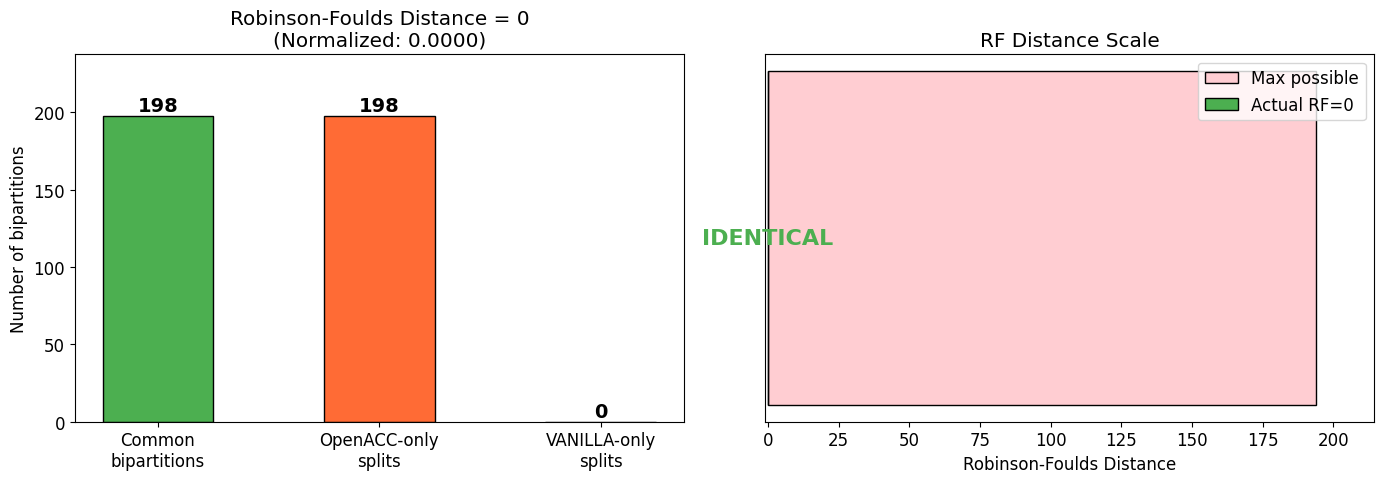

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF distance gauge
n_internal = rf_max // 2 if rf_max > 0 else 1
categories = ['Common\nbipartitions', 'OpenACC-only\nsplits', 'VANILLA-only\nsplits']
counts = [len(common_bipartitions), len(oa_unique), len(va_unique)]
bar_colors = ['#4CAF50', '#FF6B35', '#4A90D9']

bars = axes[0].bar(categories, counts, color=bar_colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Number of bipartitions')
axes[0].set_title(f'Robinson-Foulds Distance = {rf_distance}\n(Normalized: {rf_normalized:.4f})')
axes[0].set_ylim(0, max(counts) * 1.2 if max(counts) > 0 else 1)

# RF context: where does this fall on the 0-to-max scale
rf_positions = [0, rf_distance, rf_max]
rf_labels_ctx = ['Identical\n(RF=0)', f'This result\n(RF={rf_distance})', f'Max different\n(RF={rf_max})']
rf_colors_ctx = ['#4CAF50', '#FF9800', '#F44336']

axes[1].barh([0], [rf_max], color='#FFCDD2', edgecolor='black', height=0.4, label='Max possible')
axes[1].barh([0], [rf_distance], color='#4CAF50' if rf_distance == 0 else '#FF9800', 
             edgecolor='black', height=0.4, label=f'Actual RF={rf_distance}')
axes[1].set_xlabel('Robinson-Foulds Distance')
axes[1].set_title('RF Distance Scale')
axes[1].set_yticks([])
axes[1].legend(loc='upper right')
axes[1].set_xlim(-1, rf_max * 1.1 + 1)

# Add annotation
if rf_distance == 0:
    axes[1].annotate('IDENTICAL', xy=(0, 0), fontsize=16, fontweight='bold', 
                    color='#4CAF50', ha='center', va='center')

plt.tight_layout()
plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_23_treesearch/rf_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Branch Length Comparison

Statistic                        Absolute Diff        Relative Diff
Mean                                  4.63e-07             1.34e-05
Median                                3.44e-07             4.30e-06
Max                                   2.23e-06             3.95e-04
Min                                   4.00e-10             6.69e-09
Std                                   4.20e-07             3.59e-05


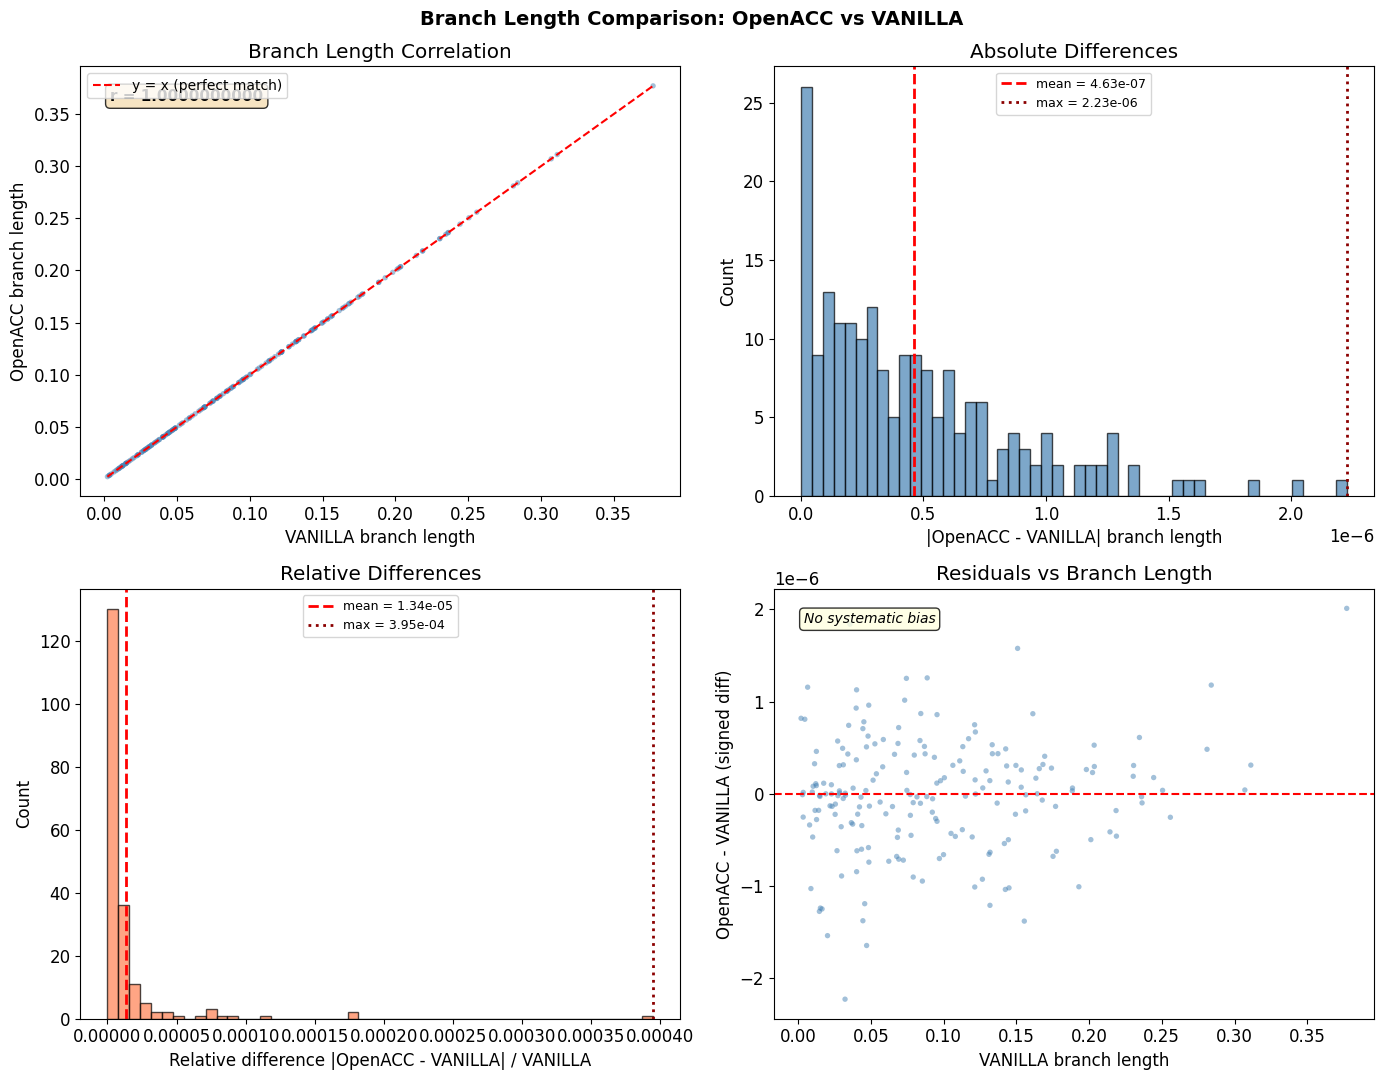

In [45]:
if len(openacc_bl) == len(vanilla_bl):
    bl_diffs = np.array(openacc_bl) - np.array(vanilla_bl)
    bl_abs_diffs = np.abs(bl_diffs)
    bl_rel_diffs = bl_abs_diffs / np.maximum(np.array(vanilla_bl), 1e-15)
    
    print(f"{'Statistic':<25} {'Absolute Diff':>20} {'Relative Diff':>20}")
    print('='*65)
    print(f"{'Mean':<25} {np.mean(bl_abs_diffs):>20.2e} {np.mean(bl_rel_diffs):>20.2e}")
    print(f"{'Median':<25} {np.median(bl_abs_diffs):>20.2e} {np.median(bl_rel_diffs):>20.2e}")
    print(f"{'Max':<25} {np.max(bl_abs_diffs):>20.2e} {np.max(bl_rel_diffs):>20.2e}")
    print(f"{'Min':<25} {np.min(bl_abs_diffs):>20.2e} {np.min(bl_rel_diffs):>20.2e}")
    print(f"{'Std':<25} {np.std(bl_abs_diffs):>20.2e} {np.std(bl_rel_diffs):>20.2e}")
    
    # Plot branch length comparison — 4 panels
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    
    # 1. Scatter: OpenACC vs VANILLA
    axes[0,0].scatter(vanilla_bl, openacc_bl, alpha=0.5, s=15, c='steelblue', edgecolors='none')
    lims = [min(min(vanilla_bl), min(openacc_bl)), max(max(vanilla_bl), max(openacc_bl))]
    axes[0,0].plot(lims, lims, 'r--', linewidth=1.5, label='y = x (perfect match)')
    axes[0,0].set_xlabel('VANILLA branch length')
    axes[0,0].set_ylabel('OpenACC branch length')
    axes[0,0].set_title('Branch Length Correlation')
    axes[0,0].legend(fontsize=10)
    
    # Correlation coefficient
    corr = np.corrcoef(vanilla_bl, openacc_bl)[0,1]
    axes[0,0].text(0.05, 0.92, f'r = {corr:.10f}', transform=axes[0,0].transAxes,
                   fontsize=11, fontweight='bold', 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 2. Histogram of absolute differences
    axes[0,1].hist(bl_abs_diffs, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0,1].set_xlabel('|OpenACC - VANILLA| branch length')
    axes[0,1].set_ylabel('Count')
    axes[0,1].set_title(f'Absolute Differences')
    axes[0,1].axvline(np.mean(bl_abs_diffs), color='red', linestyle='--', linewidth=2,
                      label=f'mean = {np.mean(bl_abs_diffs):.2e}')
    axes[0,1].axvline(np.max(bl_abs_diffs), color='darkred', linestyle=':', linewidth=2,
                      label=f'max = {np.max(bl_abs_diffs):.2e}')
    axes[0,1].legend(fontsize=9)
    
    # 3. Histogram of relative differences  
    axes[1,0].hist(bl_rel_diffs, bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[1,0].set_xlabel('Relative difference |OpenACC - VANILLA| / VANILLA')
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_title(f'Relative Differences')
    axes[1,0].axvline(np.mean(bl_rel_diffs), color='red', linestyle='--', linewidth=2,
                      label=f'mean = {np.mean(bl_rel_diffs):.2e}')
    axes[1,0].axvline(np.max(bl_rel_diffs), color='darkred', linestyle=':', linewidth=2,
                      label=f'max = {np.max(bl_rel_diffs):.2e}')
    axes[1,0].legend(fontsize=9)
    
    # 4. Signed difference vs branch length (residual plot)
    axes[1,1].scatter(vanilla_bl, bl_diffs, alpha=0.5, s=15, c='steelblue', edgecolors='none')
    axes[1,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1,1].set_xlabel('VANILLA branch length')
    axes[1,1].set_ylabel('OpenACC - VANILLA (signed diff)')
    axes[1,1].set_title('Residuals vs Branch Length')
    axes[1,1].text(0.05, 0.92, f'No systematic bias', transform=axes[1,1].transAxes,
                   fontsize=10, style='italic',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('Branch Length Comparison: OpenACC vs VANILLA', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_23_treesearch/branch_length_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Branch count mismatch: OpenACC={len(openacc_bl)}, VANILLA={len(vanilla_bl)}')

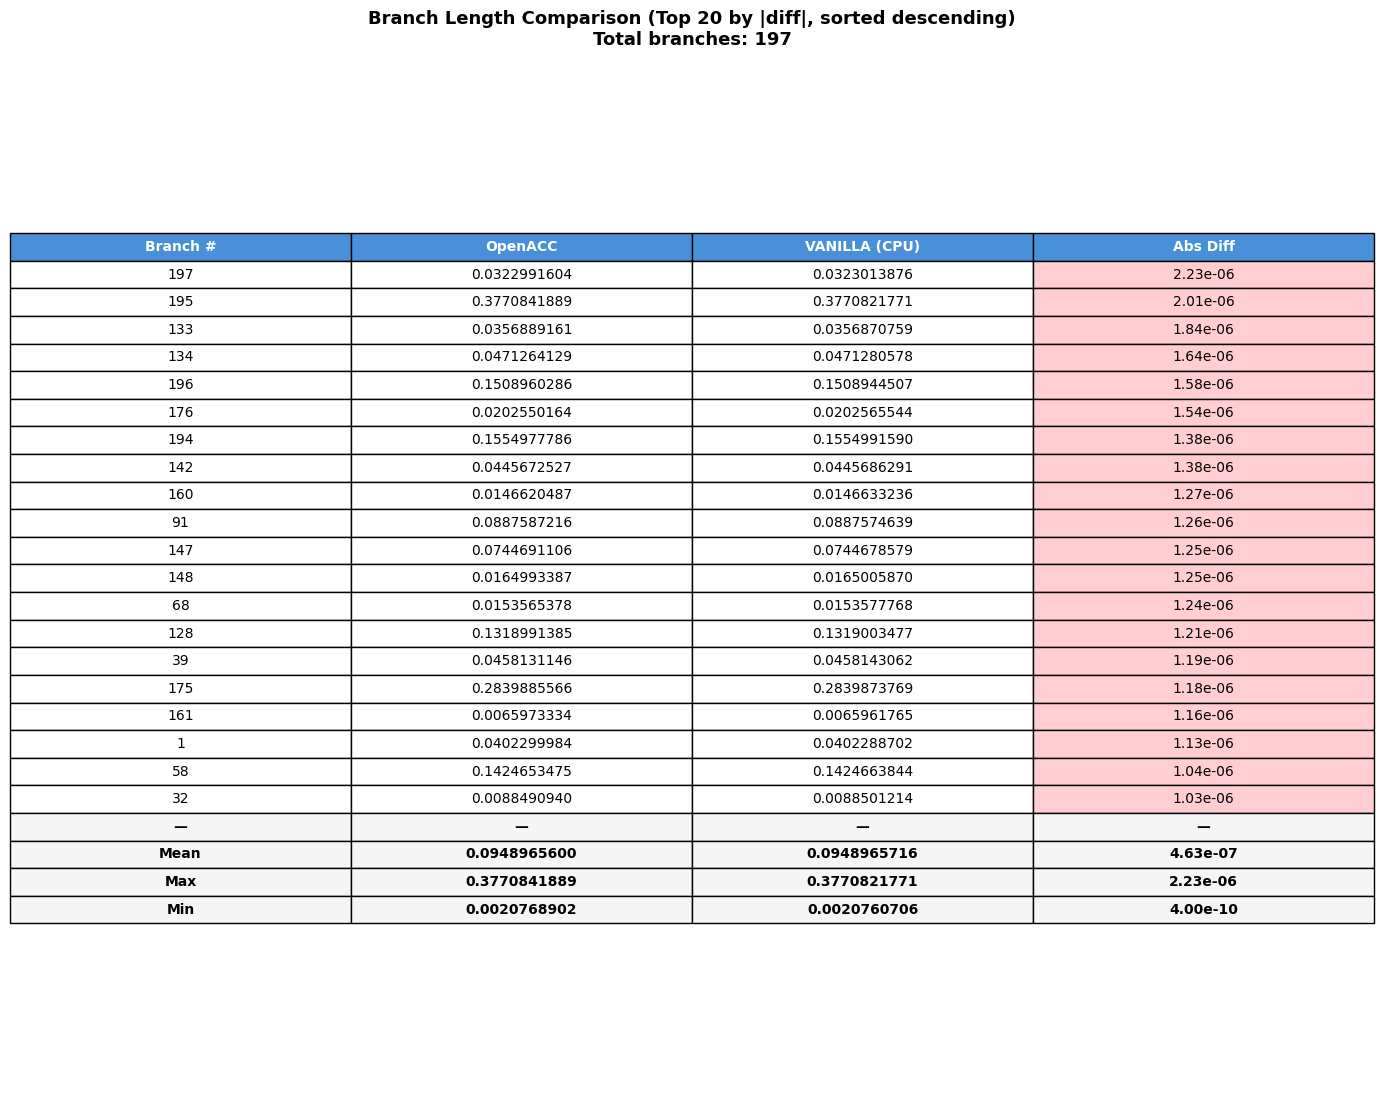


Table saved to branch_length_table.png


In [46]:

# Branch length comparison table (matplotlib)
if len(openacc_bl) == len(vanilla_bl):
    oa = np.array(openacc_bl)
    va = np.array(vanilla_bl)
    abs_diff = np.abs(oa - va)
    
    # Sort by absolute difference (largest first) for interest
    sort_idx = np.argsort(-abs_diff)
    
    # Show top 20 largest differences + summary row
    n_show = min(20, len(oa))
    show_idx = sort_idx[:n_show]
    
    # Build table data
    col_labels = ['Branch #', 'OpenACC', 'VANILLA (CPU)', 'Abs Diff']
    table_data = []
    for rank, i in enumerate(show_idx):
        table_data.append([
            f'{i+1}',
            f'{oa[i]:.10f}',
            f'{va[i]:.10f}',
            f'{abs_diff[i]:.2e}'
        ])
    # Add separator + summary stats
    table_data.append(['—', '—', '—', '—'])
    table_data.append(['Mean', f'{np.mean(oa):.10f}', f'{np.mean(va):.10f}', f'{np.mean(abs_diff):.2e}'])
    table_data.append(['Max', f'{np.max(oa):.10f}', f'{np.max(va):.10f}', f'{np.max(abs_diff):.2e}'])
    table_data.append(['Min', f'{np.min(oa):.10f}', f'{np.min(va):.10f}', f'{np.min(abs_diff):.2e}'])
    
    n_rows = len(table_data)
    fig_height = max(4, 0.4 * n_rows + 1.5)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    ax.axis('off')
    ax.set_title(f'Branch Length Comparison (Top {n_show} by |diff|, sorted descending)\n'
                 f'Total branches: {len(oa)}', fontsize=13, fontweight='bold', pad=20)
    
    table = ax.table(cellText=table_data, colLabels=col_labels,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.4)
    
    # Style header
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#4A90D9')
        table[0, j].set_text_props(color='white', fontweight='bold')
    
    # Style separator and summary rows
    for i in range(n_show, n_rows):
        for j in range(len(col_labels)):
            table[i+1, j].set_facecolor('#F5F5F5')
            table[i+1, j].set_text_props(fontweight='bold')
    
    # Color-code abs diff column by magnitude
    for i in range(n_show):
        val = abs_diff[show_idx[i]]
        if val < 1e-7:
            color = '#E8F5E9'  # green — tiny
        elif val < 1e-6:
            color = '#FFF9C4'  # yellow — small
        else:
            color = '#FFCDD2'  # red — larger
        table[i+1, 3].set_facecolor(color)
    
    plt.tight_layout()
    plt.savefig('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_23_treesearch/branch_length_table.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nTable saved to branch_length_table.png')
else:
    print(f'Branch count mismatch: OpenACC={len(openacc_bl)}, VANILLA={len(vanilla_bl)}')


## 6. Performance Comparison

In [47]:
# Performance table
print(f"{'Metric':<35} {'OpenACC (GPU)':>18} {'VANILLA (1 CPU)':>18} {'Ratio':>12}")
print('='*83)

ts_wall_ratio = openacc['treesearch_wall'] / vanilla['treesearch_wall']
total_wall_ratio = openacc['total_wall'] / vanilla['total_wall']

print(f"{'Tree search wall-clock (s)':<35} {openacc['treesearch_wall']:>18.2f} {vanilla['treesearch_wall']:>18.2f} {ts_wall_ratio:>11.2f}x")
print(f"{'Tree search CPU time (s)':<35} {openacc['treesearch_cpu']:>18.2f} {vanilla['treesearch_cpu']:>18.2f} {openacc['treesearch_cpu']/vanilla['treesearch_cpu']:>11.2f}x")
print(f"{'Total wall-clock (s)':<35} {openacc['total_wall']:>18.2f} {vanilla['total_wall']:>18.2f} {total_wall_ratio:>11.2f}x")
print(f"{'Total CPU time (s)':<35} {openacc['total_cpu']:>18.2f} {vanilla['total_cpu']:>18.2f} {openacc['total_cpu']/vanilla['total_cpu']:>11.2f}x")
print()

if ts_wall_ratio < 1.0:
    print(f'🚀 GPU tree search is {1/ts_wall_ratio:.2f}x FASTER than 1-thread CPU')
elif ts_wall_ratio < 1.1:
    print(f'≈  GPU tree search is roughly equal to 1-thread CPU ({ts_wall_ratio:.2f}x)')
else:
    print(f'🐌 GPU tree search is {ts_wall_ratio:.2f}x SLOWER than 1-thread CPU')

Metric                                   OpenACC (GPU)    VANILLA (1 CPU)        Ratio
Tree search wall-clock (s)                      260.59             151.03        1.73x
Tree search CPU time (s)                        260.54             150.07        1.74x
Total wall-clock (s)                            261.92             152.40        1.72x
Total CPU time (s)                              261.85             151.41        1.73x

🐌 GPU tree search is 1.73x SLOWER than 1-thread CPU


In [48]:
## 7. Summary

print('='*70)
print('TREE SEARCH RESULTS SUMMARY')
print('='*70)
print(f'Dataset: DNA, 100 taxa, 10,000 sites, GTR (fixed model params)')
print(f'OpenACC: V100 GPU, 1 thread  |  VANILLA: AVX+FMA CPU, 1 thread')
print('='*70)
print()
print('CORRECTNESS:')
print(f'  logL difference:      {logl_diff:.2e} (relative: {logl_reldiff:.2e})')
print(f'  Topology match:       {topo_match}')
print(f'  RF distance:          {rf_distance} / {rf_max} (normalized: {rf_normalized:.4f})')
print(f'  Common bipartitions:  {len(common_bipartitions)}')
print(f'  OpenACC-only splits:  {len(oa_unique)}')
print(f'  VANILLA-only splits:  {len(va_unique)}')
print(f'  Same iterations:      {openacc["iterations"]} vs {vanilla["iterations"]}')
print(f'  Same NNI rounds:      {openacc["nni_rounds"]} vs {vanilla["nni_rounds"]}')
if len(openacc_bl) == len(vanilla_bl):
    print(f'  Max branch len diff:  {np.max(bl_abs_diffs):.2e}')
    print(f'  Mean branch len diff: {np.mean(bl_abs_diffs):.2e}')
print()
print('PERFORMANCE:')
print(f'  Tree search:  OpenACC {openacc["treesearch_wall"]:.1f}s vs VANILLA {vanilla["treesearch_wall"]:.1f}s ({ts_wall_ratio:.2f}x)')
print(f'  Total:        OpenACC {openacc["total_wall"]:.1f}s vs VANILLA {vanilla["total_wall"]:.1f}s ({total_wall_ratio:.2f}x)')
print()
if rf_distance == 0:
    print('TOPOLOGY: IDENTICAL (RF = 0)')
elif rf_normalized < 0.05:
    print(f'TOPOLOGY: Nearly identical (RF = {rf_distance}, {rf_normalized:.1%} of max)')
else:
    print(f'TOPOLOGY: Different (RF = {rf_distance}, {rf_normalized:.1%} of max)')
print()
if ts_wall_ratio > 1.0:
    print(f'NOTE: GPU is {ts_wall_ratio:.2f}x slower than 1-thread CPU.')
    print('  This is expected for the initial implementation:')
    print('  - NNI evaluates branches one at a time (serial host loop)')
    print('  - Each evaluation launches multiple GPU kernels (high launch overhead)')
    print('  - computeLikelihoodFromBuffer falls through to full GPU traversal')
    print('  - No batching of NNI evaluations across branches')
    print()
    print('  Future optimizations:')
    print('  - Implement computeLikelihoodFromBufferOpenACC (theta buffer)')
    print('  - Batch multiple NNI evaluations')
    print('  - Traversal cache (avoid rebuild when topology unchanged)')
    print('  - Larger datasets will show better GPU utilization')

In [49]:
print('='*70)
print('TREE SEARCH RESULTS SUMMARY')
print('='*70)
print(f'Dataset: DNA, 100 taxa, 10,000 sites, GTR (fixed model params)')
print(f'OpenACC: V100 GPU, 1 thread  |  VANILLA: AVX+FMA CPU, 1 thread')
print('='*70)
print()
print('CORRECTNESS:')
print(f'  logL difference:      {logl_diff:.2e} (relative: {logl_reldiff:.2e})')
print(f'  Topology match:       {topo_match}')
print(f'  Same iterations:      {openacc["iterations"]} vs {vanilla["iterations"]}')
print(f'  Same NNI rounds:      {openacc["nni_rounds"]} vs {vanilla["nni_rounds"]}')
if len(openacc_bl) == len(vanilla_bl):
    print(f'  Max branch len diff:  {np.max(bl_abs_diffs):.2e}')
    print(f'  Mean branch len diff: {np.mean(bl_abs_diffs):.2e}')
print()
print('PERFORMANCE:')
print(f'  Tree search:  OpenACC {openacc["treesearch_wall"]:.1f}s vs VANILLA {vanilla["treesearch_wall"]:.1f}s ({ts_wall_ratio:.2f}x)')
print(f'  Total:        OpenACC {openacc["total_wall"]:.1f}s vs VANILLA {vanilla["total_wall"]:.1f}s ({total_wall_ratio:.2f}x)')
print()
if ts_wall_ratio > 1.0:
    print(f'NOTE: GPU is {ts_wall_ratio:.2f}x slower than 1-thread CPU.')
    print('  This is expected for the initial implementation:')
    print('  - NNI evaluates branches one at a time (serial host loop)')
    print('  - Each evaluation launches multiple GPU kernels (high launch overhead)')
    print('  - computeLikelihoodFromBuffer falls through to full GPU traversal')
    print('  - No batching of NNI evaluations across branches')
    print()
    print('  Future optimizations:')
    print('  - Implement computeLikelihoodFromBufferOpenACC (theta buffer)')
    print('  - Batch multiple NNI evaluations')
    print('  - Traversal cache (avoid rebuild when topology unchanged)')
    print('  - Larger datasets will show better GPU utilization')

TREE SEARCH RESULTS SUMMARY
Dataset: DNA, 100 taxa, 10,000 sites, GTR (fixed model params)
OpenACC: V100 GPU, 1 thread  |  VANILLA: AVX+FMA CPU, 1 thread

CORRECTNESS:
  logL difference:      0.00e+00 (relative: 0.00e+00)
  Topology match:       True
  Same iterations:      102 vs 102
  Same NNI rounds:      0 vs 0
  Max branch len diff:  2.23e-06
  Mean branch len diff: 4.63e-07

PERFORMANCE:
  Tree search:  OpenACC 260.6s vs VANILLA 151.0s (1.73x)
  Total:        OpenACC 261.9s vs VANILLA 152.4s (1.72x)

NOTE: GPU is 1.73x slower than 1-thread CPU.
  This is expected for the initial implementation:
  - NNI evaluates branches one at a time (serial host loop)
  - Each evaluation launches multiple GPU kernels (high launch overhead)
  - computeLikelihoodFromBuffer falls through to full GPU traversal
  - No batching of NNI evaluations across branches

  Future optimizations:
  - Implement computeLikelihoodFromBufferOpenACC (theta buffer)
  - Batch multiple NNI evaluations
  - Traversal ca